## Select a FITS file

Set `data_root` to your top-level `DataDirectories` folder. `choose_file()` now handles either case: a folder containing FITS files directly, or a folder containing subdirectories of FITS files.


In [3]:
config = ImagingConfig()
image_path = choose_file(config.data_root, extensions=(".fits", ".fit"))
image_path


Directory#   Directory
----------------------------------------------------------------------
    0       Archive
    1       CowTests
    2       Images
    3       Lib-0610
    4       Patio-0629
    5       Patio-0703
----------------------------------------------------------------------


Choose directory number:  4



File#       File
----------------------------------------------------------------------
    0       Altair-Bahtinov_2026-06-29_08.15.59_CuED-0.fits
    1       Altair-Bahtinov_2026-06-29_08.15.59_CuED_0_sum.fits
    2       Altair-Bahtinov_2026-06-29_08.21.48_CuED-0.fits
    3       Altair-Bahtinov_2026-06-29_08.26.49_CuED-0.fits
    4       M15_2026-06-29_10.20.58_CuED_10_sum.fits
    5       M57_2026-06-29_10.06.46_CuED_5_sum.fits
    6       M71_2026-06-29_10.11.32_CuED_10_sum.fits
    7       Neptune_2026-06-29_10.30.12_CuED-0.fits
    8       Neptune_2026-06-29_10.30.12_CuED_4_sum.fits
    9       Neptune_2026-06-29_10.40.37_CuED-0.fits
   10       Neptune_2026-06-29_10.40.37_CuED_4_sum.fits
   11       Polaris_2026-06-29_08.56.03_CuED_5_sum.fits
   12       Polaris_2026-06-29_08.59.05_CuED-0.fits
   13       Saturn_2026-06-29_10.45.04_CuED-0.fits
   14       Saturn_2026-06-29_10.45.04_CuED_9_sum.fits
   15       Vega-Bahtinov_2026-06-29_09.26.41_CuED-0.fits
   16       VegaBC_20

Enter file number to analyze:  9


PosixPath('/Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories/Patio-0629/Neptune_2026-06-29_10.40.37_CuED-0.fits')

In [5]:
from fits_imaging.analysis import analyze_image

results = analyze_image(image_path, config)
results.print_summary()

Neptune  9576 x 6380  Apx60-CuED  2.513 sec
RAH:   0.283  Dec:   0.348  PA: 315.64  PA2:  44.36  Alt:    31.5  Az:   117.8
Mean: 302.5  Median: 301.0  Std: 29.8  Min: 91.0  Max: 37624.0
Found 98 peaks in 2.80 sec


In [7]:
csv_path = results.export_csv("peak_table.csv", config=config)
csv_path

PosixPath('peak_table.csv')

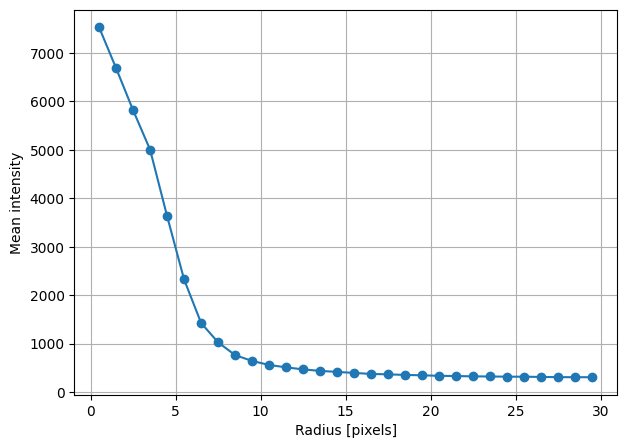

In [9]:
r, prof = results.radial_profile(peak_index=0, rmax=30)

plt.figure(figsize=(7, 5))
plt.plot(r, prof, marker="o")
plt.xlabel("Radius [pixels]")
plt.ylabel("Mean intensity")
plt.grid(True)
plt.show()

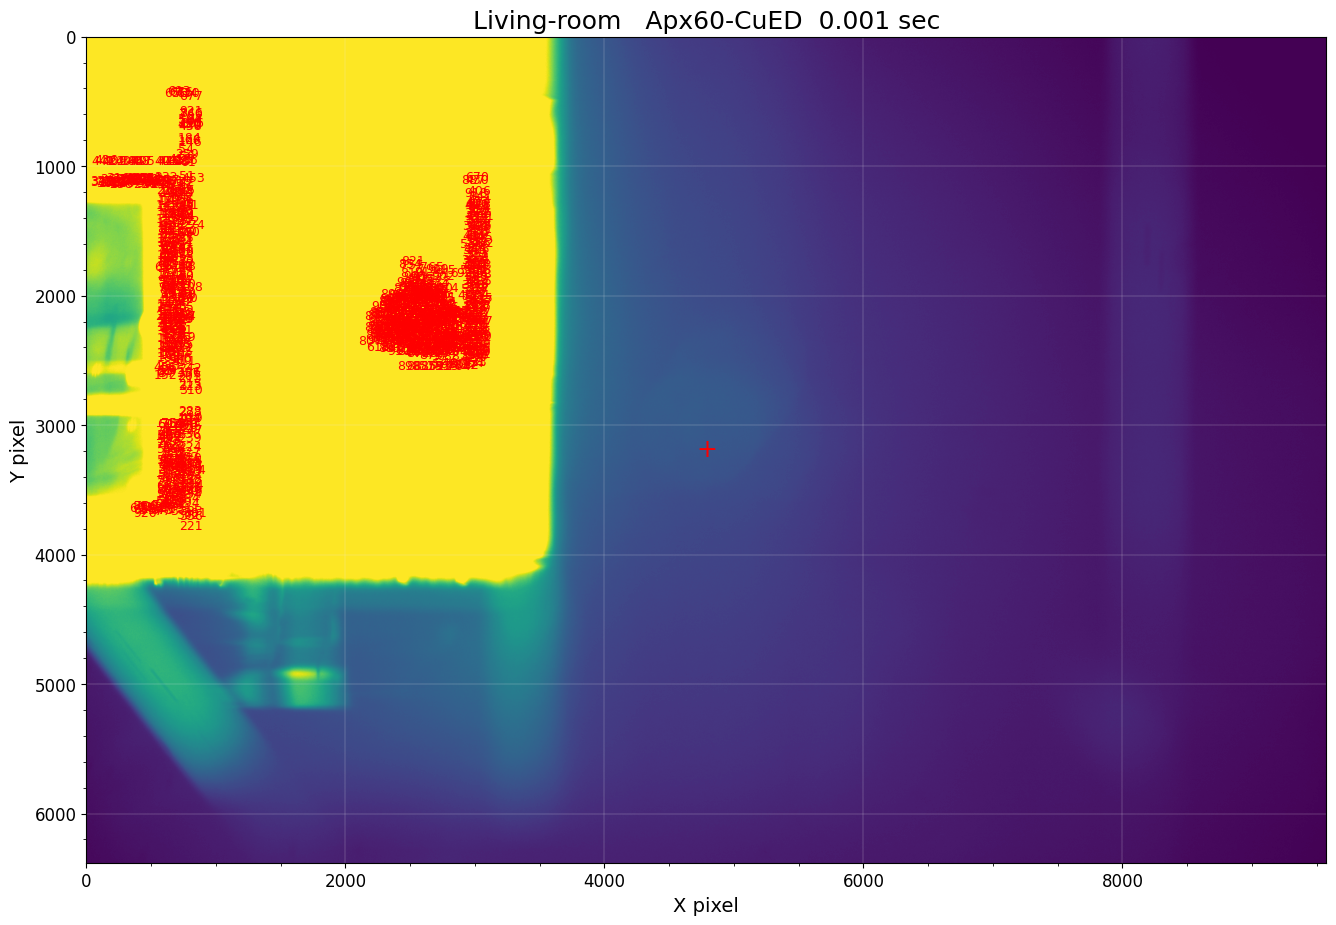


Peak#        X        Y        Area       sx      sy        Flux      Mag
------------------------------------------------------------------------------
    0    537.40   2644.39 127738584.0    7.60   42.73   2008328.0   -3.105
    1    708.42   2337.20 315448576.0   41.40   59.32   1910982.0   -3.051
    2    707.91   1851.37 1880250752.0   47.67  170.38   1905473.0   -3.048
    3    709.22   2379.82 394647232.0   37.08   72.07   1904316.0   -3.048
    4    711.55   2324.96 406098880.0   59.36   56.63   1904049.0   -3.047
    5    709.35   1825.23 302901376.0   40.35   58.43   1903446.0   -3.047
    6    708.52   2297.07 846920768.0   29.69  115.02   1900662.0   -3.046
    7    708.19   1919.97 324004064.0   39.33   62.08   1900579.0   -3.045
    8    707.70   2248.77 413609952.0   32.92   76.17   1899077.0   -3.045
    9    708.50   2150.41 3622947782656.0   46.02 7772.95   1896278.0   -3.043
   10    709.85   1784.03 1151089152.0   58.40  125.90   1895981.0   -3.043
   11    706.62

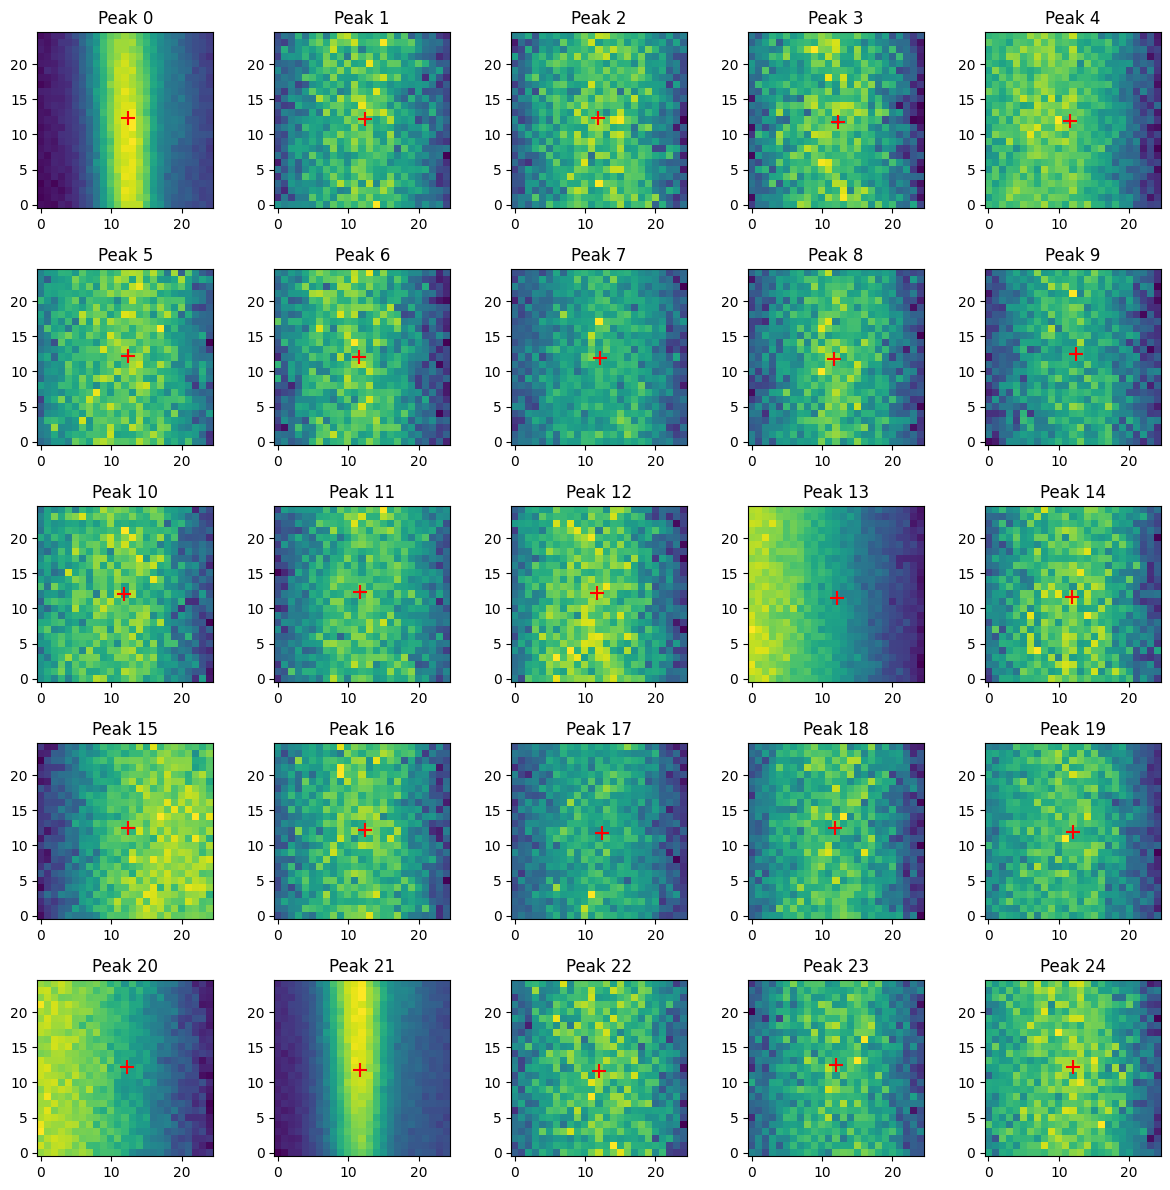

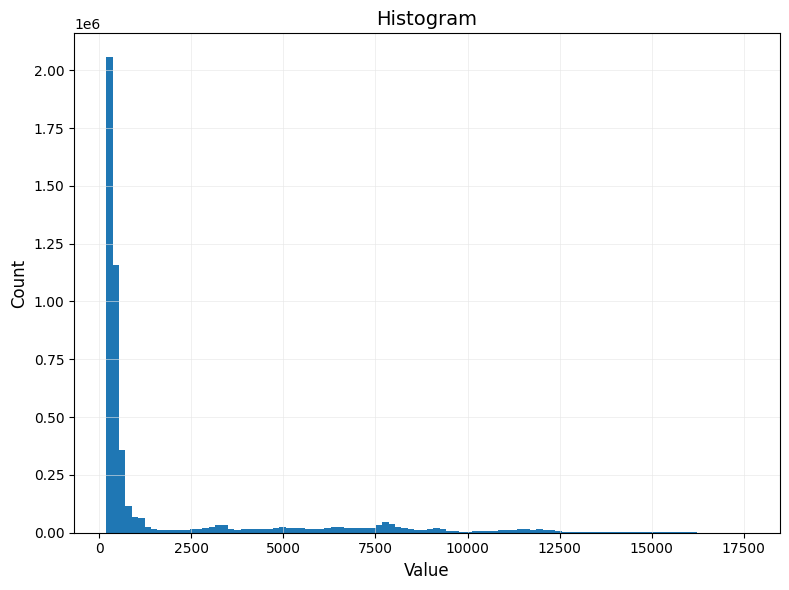

In [17]:

fig, ax = results.plot_image(config=config, figsize=(16, 16))
plt.show()

results.print_peak_table(config=config, max_rows=200)

fig, axs = results.plot_cutouts(
    config=config,
    nmax=25,
    spansize=24,
    pixel_arcsec=config.pixel_arcsec,
    exposure_sec=results.exposure_sec,
    zero_mag_counts=config.zero_mag_counts,
)
plt.show()

fig, ax = results.plot_histogram(config=config)
plt.show()

# This is an older approach that is kept for historical reference

## Read image and find peaks

In [14]:
record, imagec, peaksarray, stats = analyze_fits_file(
    image_path,
    peak_separation=10.0,
    peak_sharp=0.2,
    maxsources=400,
    fit_method='gaussian',   # use 'moments' for faster center-of-light estimates
)

print_image_summary(record, imagec, stats)

Neptune  9576 x 6380  Apx60-CuED  2.513 sec
RAH:   0.283  Dec:   0.348  PA: 315.64  PA2:  44.36  Alt:    31.5  Az:   117.8
Mean: 302.5  Median: 301.0  Std: 29.8  Min: 91.0  Max: 37624.0
Found 98 peaks in 2.74 sec


## Full image with labeled peaks

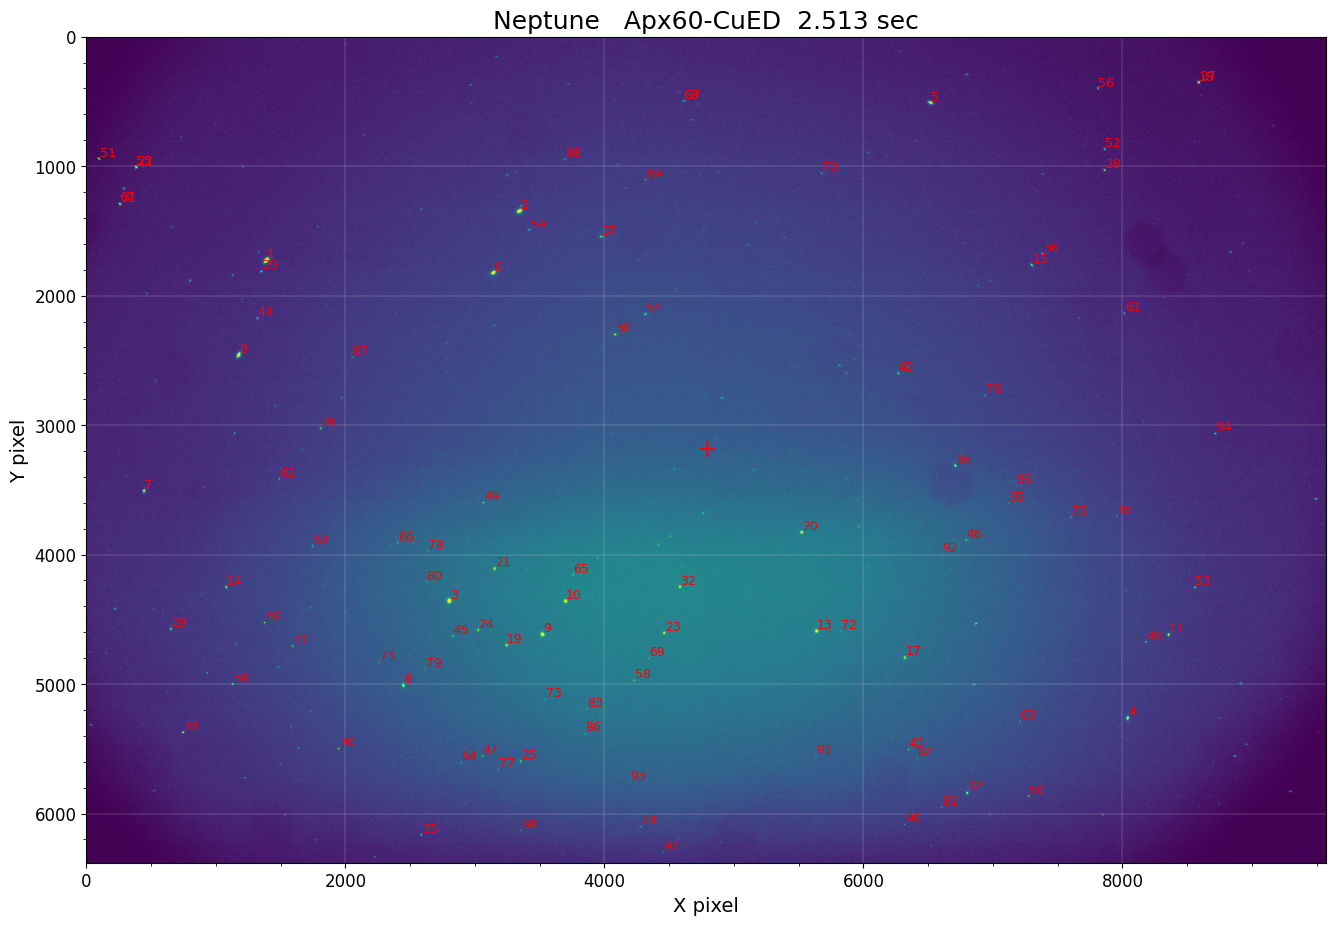

In [16]:
title = f'{record.object_name}   {record.camera}  {record.exposure_sec:.3f} sec'
fig, ax = plot_image_with_peaks(
    imagec,
    peaksarray,
    title=title,
    figsize=(16, 16),
    config=config,
)
plt.show()

## Peak table

In [9]:
swarpfac = -1.0 if record.softname == 'SWarp' else 1.0
print_peak_table(
    peaksarray,
    exposure_sec=record.exposure_sec,
    zero_mag_counts=config.zero_mag_counts,
    pa0=record.pa_deg,
    swarpfac=swarpfac,
    max_rows=200,
)


Peak#        X        Y        Area       sx      sy        Flux      Mag
------------------------------------------------------------------------------
    0   1177.55   2458.14    613561.6    3.93    3.46    412565.0    7.113
    1   1392.36   1726.46    408838.0    4.29    4.66    221865.0    7.787
    2   3345.88   1348.74    223432.6    3.11    2.13    189235.0    7.960
    3   2804.54   4357.14    167160.5    1.38    2.54    155481.0    8.173
    4   8045.11   5260.66    213413.9    3.72    3.00    151463.0    8.201
    5   6522.11    511.26    189935.2    3.53    3.28    138421.0    8.299
    6   3144.93   1824.45    147813.7    2.67    2.34    137781.0    8.304
    7    447.36   3507.63    172392.4    5.16    3.04     89506.0    8.773
    8   2450.95   5010.83     86552.6    1.62    2.08     86442.0    8.810
    9   3524.00   4615.77     75465.9    1.81    2.45     77563.0    8.928
   10   3702.84   4360.11     73996.7    2.28    2.72     69531.0    9.047
   11   8360.88   461

## Peak cutouts

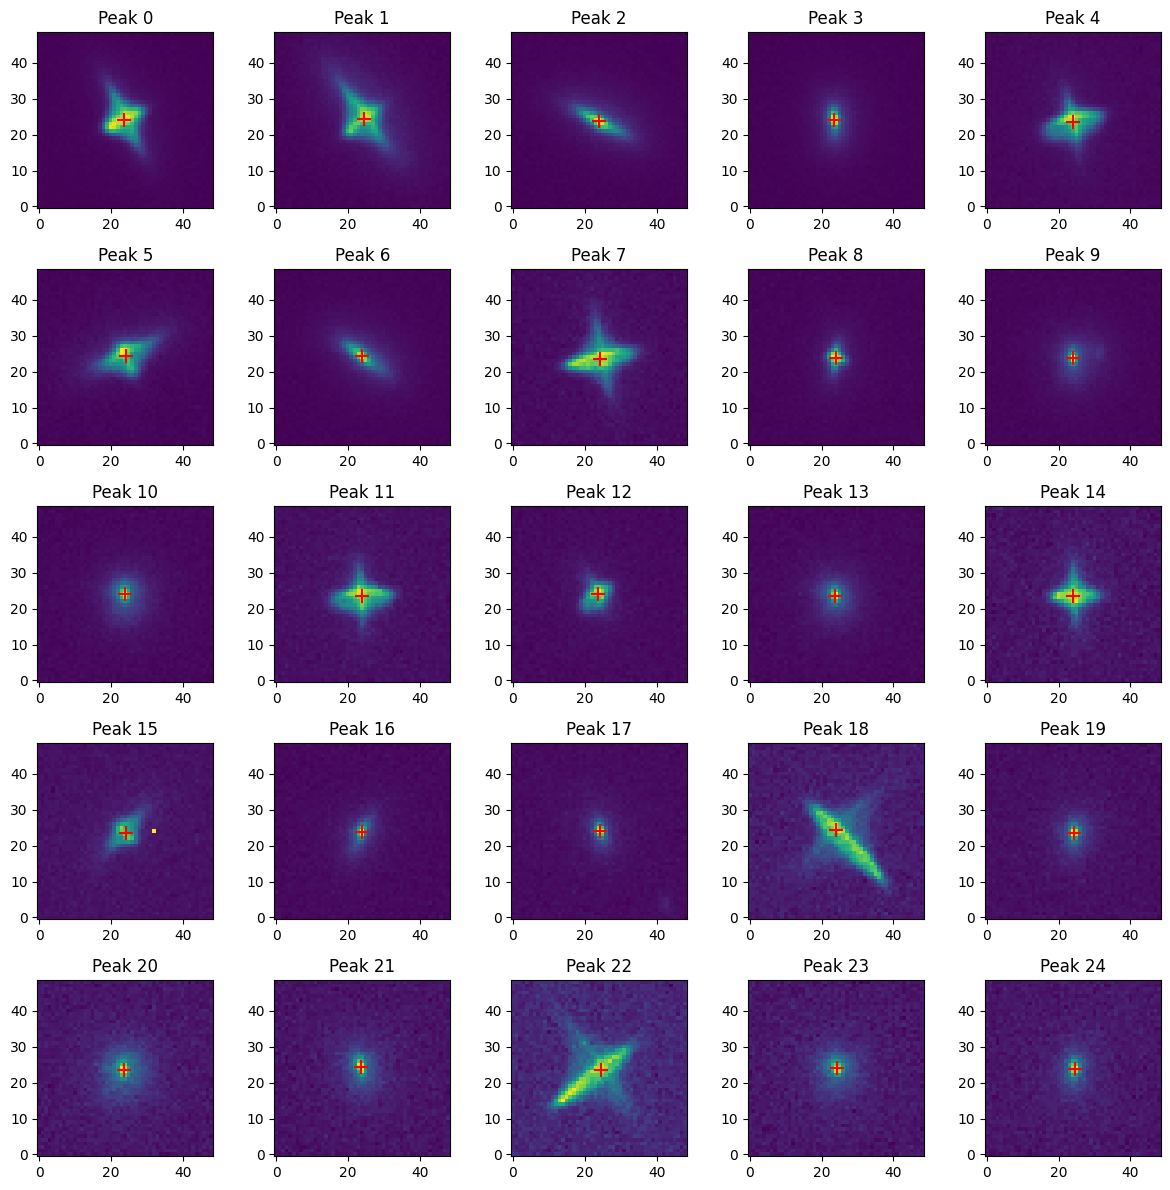

In [13]:
if len(peaksarray) > 0:
    fig, axs = plot_peak_cutouts(
        imagec,
        peaksarray,
        nmax=25,
        spansize=48,
        pixel_arcsec=config.pixel_arcsec,
        exposure_sec=record.exposure_sec,
        zero_mag_counts=config.zero_mag_counts,
    )
    plt.show()
else:
    print('No peaks found.')

## Optional diagnostic plots

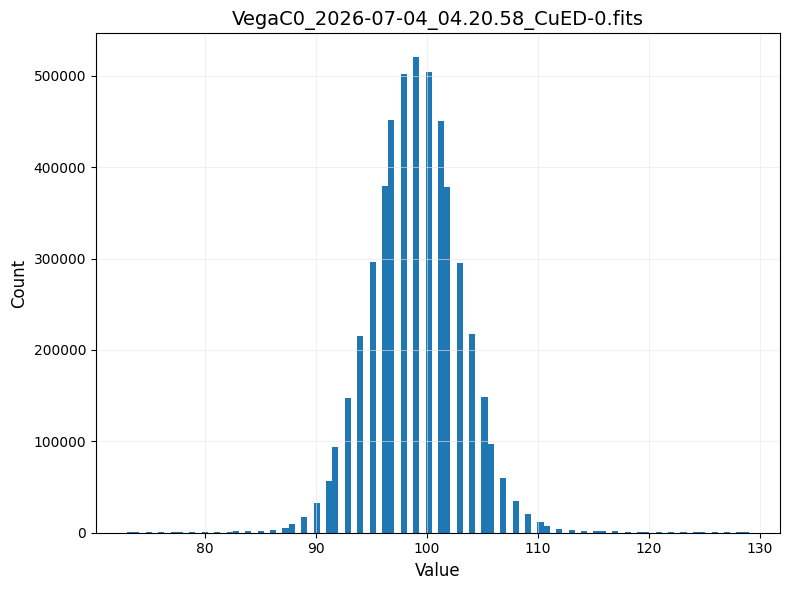

In [13]:
fig, ax = plot_histogram(imagec, title=record.filename)
plt.show()

In [ ]:
convolved_image, fig, ax = plot_convolved_image(imagec, title=f'{record.filename}: W5x5 convolution')
plt.show()